In [1]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
from mpl_toolkits.axes_grid1 import host_subplot
from matplotlib import rcParams
import matplotlib.cm as cmap

from defs import *

%load_ext autoreload
%autoreload 2

# Band structure plot

In [2]:
home_dir = '../../../'
raw_dir = home_dir + 'data/kagome-02.26.2022-center/raw/'
processed_dir = home_dir + 'data/kagome-02.26.2022-center/preprocessed_band/'
out_dir = home_dir + 'output/paper_upload/'

# Plot output toggles
SHOW_PLOT_DECORATIONS = False  # False hides labels, tick labels, legends, and titles.
SAVE_PLOT = True  # False displays figures without saving them.

In [3]:
# Preprocess raw chirp data
freq = np.linspace(1000.0, 18000.0, 426)
preprocess_chirp(
    data_dir=raw_dir+'band_structure/',
    frequencies=freq,
    targetfile=processed_dir,
    title='scppos_',
    setno=0,
)

Found 185 records
Preprocessing complete!


## 2. Generate k-Space Sweep

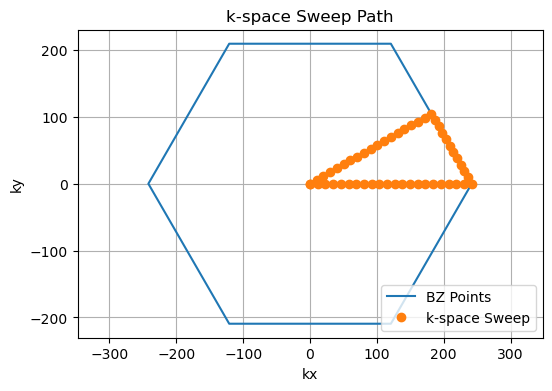

In [4]:
# Define points in reciprocal space for the sweep
L = 0.01 * np.sqrt(3) / 2  # nearest neighbor distance in real space
G = np.array([0, 0])
K = np.array([2 * np.pi / (3 * L), 0])
M = np.array([3 / 2 * np.pi / 3 / L, np.pi / np.sqrt(3) / 2 / L])

b_res = 50

rcParams.update({'font.size': 10, 'axes.labelsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

b, kxb, kyb = generate_k_space_sweep([G, K, M, G], num_points=b_res)
BZ_points = rotate_points(K, np.linspace(0, 2 * np.pi, 7, endpoint=True))
visualize_sweep((kxb, kyb), BZ_points)

## 3. Fourier Transform

In [5]:
# Load the preprocessed data from processed_dir. Then extract the frequency points
fns = glob.glob(processed_dir + '*.pkl')
freqs = [float(fn.split('_')[2].split('.')[0]) for fn in fns if fn.endswith('.pkl')]

# sort the frequencies and corresponding file names
sorted_indices = np.argsort(freqs)
freqs = np.array(freqs)[sorted_indices]
fns = np.array(fns)[sorted_indices]

In [6]:
lat_vecs = np.array([[4, 0], [2, 2]])
sub_lat_vecs = np.array([[0, 0], [1, 1], [3, 1]])

x_unit = 10 * np.sqrt(3) / 4
y_unit = 10 * 3 / 4

reciprocal_data = np.zeros((len(sub_lat_vecs), len(freqs), len(kxb)))

rot_angles = np.linspace(0, 2 * np.pi, 6, endpoint=False)


for i in tqdm(range(len(freqs))):
    real_data = pickle.load(open(fns[i], 'rb'))

    # Clear sublattice lists for each iteration
    sublat_data = [[], [], []]

    # Sort the real data into the 3 sublattices
    for point in real_data:
        sub_lat = return_sublat_triangle([0, 0], np.array([point[0], point[1]]), lat_vecs, sub_lat_vecs)
        point[0] *= x_unit/1000
        point[1] *= y_unit/1000

        if sub_lat != -1:
            sublat_data[sub_lat].append(point)


    # Calculate the symmetrized Fourier amplitude for each sublattice at each k-point in the sweep
    for j in range(len(kxb)):
        kx_ops, ky_ops = symmetry_k_points(kxb[j], kyb[j], rot_angles)
        for sub_lat_idx in range(len(sub_lat_vecs)):
            reciprocal_data[sub_lat_idx, i, j] = fourier_symmetrized_amplitude(sublat_data[sub_lat_idx], kx_ops, ky_ops)

reciprocal_data = np.average(reciprocal_data, axis=0)

  0%|          | 0/426 [00:00<?, ?it/s]

In [ ]:
# Load the COMSOL-simulated kagome band structure for comparison.
simulated_band_structure = extract_band_structure(
    home_dir + 'data/simulation/extkag_0_fluid_custom_mesh_allbands.csv',
    max_bands=3,
    band_selection='top',
)
b_sim = np.asarray(
    list(simulated_band_structure['frequencies_by_b_hz'])
)
bands_sim = band_frequency_matrix(simulated_band_structure).T / 1e3

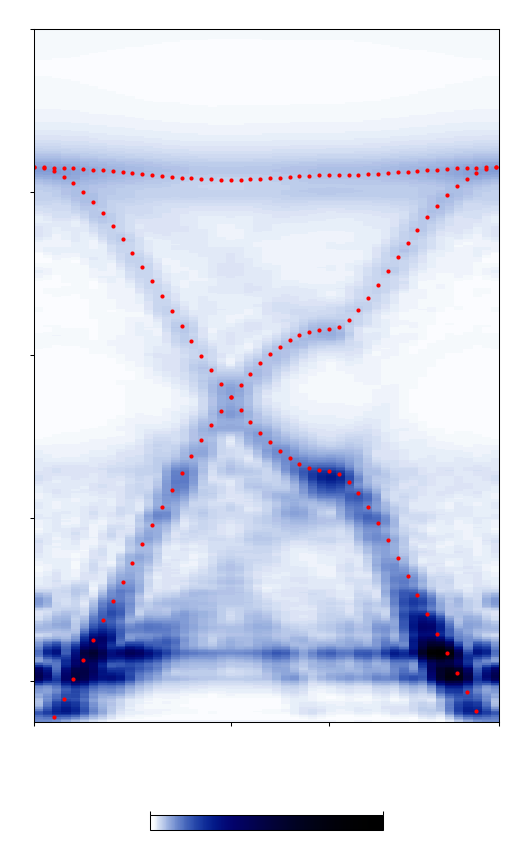

In [8]:
reciprocal_data_plot = reciprocal_data/np.max(reciprocal_data)

b_norm = np.linspace(0, (1+np.sqrt(3)/2+1/2), len(b))  # Normalize b to match the simulation range


fig, ax = plt.subplots(figsize = (2, 4), dpi = 300)
ax.axis([b_norm[0], b_norm[-1], freqs[0]/1000, freqs[-1]/1000])
b_mesh, freq_mesh = np.meshgrid(b, freqs / 1000)

# Plot the experimental band structure as a heatmap
plt.imshow(
    reciprocal_data_plot,
    extent=[b_norm[0], b_norm[-1], freqs[0]/1000, freqs[-1]/1000],
    origin='lower',
    aspect='auto',
    interpolation='none',
    cmap=stmpy.cm.blue3_r
)

# Overlay the simulated band structure as red points
for band_sim in bands_sim:
    ax.plot(b_sim, band_sim, 'r.', markersize=2, fillstyle='full', markeredgewidth=0)


cb = plt.colorbar(ticks = [0,1], location='bottom', pad=0.1, aspect=15, shrink=0.5)
cb.set_ticks([0, 1])
cb.ax.tick_params(labelsize=5)
cb.ax.xaxis.set_tick_params(width=0.25, length = 1)
cb.ax.xaxis.set_ticks_position('top')
cb.outline.set_linewidth(0.25)
cb.set_label(r'|$\tilde{p}(\mathbf{k}, f)$| (A.U.)', fontsize=5, labelpad=2)


ax.set_yticks(np.linspace(2, 18, 5))
ax.set_xticks([0, 1, 1.5, b_norm[-1]], labels=['Γ', 'K', 'M', 'Γ'])
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)
ax.tick_params(axis='both', labelsize=5)
ax.set_ylabel('Frequency (kHz)', fontsize=5)
ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)

if not SHOW_PLOT_DECORATIONS:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)
    cb.set_label('')
    cb.ax.tick_params(labelbottom=False, labeltop=False)
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

if SAVE_PLOT:
    fig.savefig(out_dir + 'band_structure.pdf', bbox_inches='tight')



# Cavity frequency responses

In [9]:
# Define shared parameters

preamp_gain = 4.731513 
mic_gain = 0.02 #0.02V/Pa 

freq_cut = (5, 18)  # in kHz
freq_mask = (freqs >= freq_cut[0]*1000) & (freqs <= freq_cut[1]*1000)

## Average frequency response

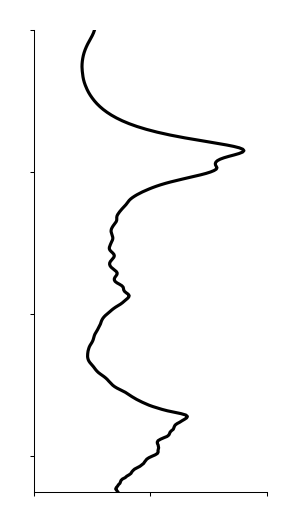

In [10]:
avg_dir = raw_dir + 'avg/'
fns_avg = glob.glob(avg_dir + '*.pkl')

for i, file in enumerate(fns_avg):
    with open(file, 'rb') as f:
        data = pickle.load(f)
        if i == 0:
            amp_avg = data[:,1]
        else:
            amp_avg += data[:,1]
        
amp_avg /= len(fns_avg)
amp_avg /= preamp_gain*mic_gain


plt.figure(figsize=(1,2), dpi=300)
plt.plot(amp_avg[freq_mask], freqs[freq_mask]/1000, 'k', linewidth = 0.75)

plt.axis([0, 2, freq_cut[0], freq_cut[1]])
plt.xticks(np.linspace(0, 2, 3), fontsize=5)
plt.yticks(np.linspace(6, 18, 4), fontsize=5)
plt.xlabel(r'$A(\mathbf{r}, f)$ (Pa)', fontsize=5)
plt.ylabel('Frequency (kHz)', fontsize=5)

ax = plt.gca()
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)
ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

if not SHOW_PLOT_DECORATIONS:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

if SAVE_PLOT:
    plt.savefig(out_dir + "avg_response_plot.pdf", bbox_inches='tight')



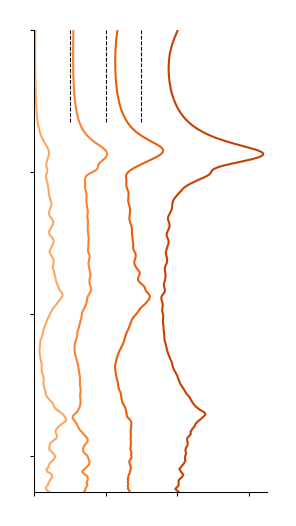

In [11]:
line_num = 4
shift = np.linspace(0, 3, line_num)
color = cmap.Oranges_r(np.linspace(0.2, 0.6, line_num))

response_dir = raw_dir + 'band_structure/'
fns = [f'scppos_{i}_{i}' for i in range(1, line_num+1)]

plt.figure(figsize=(1,2), dpi=300)

for i, fn in enumerate(fns):
    filepath = response_dir+fn+'.pkl'
    with open(filepath, 'rb') as f:
        amplitude = pickle.load(f)[:,1]
    
    amplitude /= preamp_gain*mic_gain
    
    plt.plot(amplitude[freq_mask] + shift[line_num-i-1], freqs[freq_mask]/1000, color = color[i], linestyle = '-', linewidth = 0.5)
    plt.axvline(x=shift[i], ymin=0.8, ymax=1, color='k', linestyle='--', linewidth=0.25)

    
plt.axis([0, 6.5, freq_cut[0], freq_cut[1]])
plt.xticks(np.linspace(0, 6, 4), fontsize=5)
plt.yticks(np.linspace(6, 18, 4), fontsize=5)
plt.xlabel(r'$A(\mathbf{r}, f)$ (Pa)', fontsize=5)
plt.ylabel('Frequency (kHz)', fontsize=5)

ax = plt.gca()
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(0.25)
ax.xaxis.set_tick_params(width=0.25, length = 1)
ax.yaxis.set_tick_params(width=0.25, length = 1)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

if not SHOW_PLOT_DECORATIONS:
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_title('')
    ax.tick_params(axis='x', labelbottom=False)
    ax.tick_params(axis='y', labelleft=False)
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

if SAVE_PLOT:
    plt.savefig(out_dir + "waterfall_plot.pdf", bbox_inches='tight')